In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.3 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os
import zipfile
import subprocess

# Lista dos novos arquivos zip
zip_files = [
    "/content/100_imagens_celulares.zip",
    "/content/520_imagens_celulares.zip",
    "/content/1300_imagens_celulares.zip"
]
extract_dir = "/content/mobile_phone_dataset"

os.makedirs(extract_dir, exist_ok=True)

for zip_path in zip_files:
    if os.path.exists(zip_path):
        print(f"--- Processando: {os.path.basename(zip_path)} ---")
        file_size = os.path.getsize(zip_path)
        print(f"Tamanho: {file_size} bytes")

        try:
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                zip_ref.extractall(extract_dir)
            print(f"Sucesso ao extrair {zip_path}")
        except zipfile.BadZipFile:
            print(f"Erro: O arquivo {zip_path} está corrompido.")
    else:
        print(f"Aviso: Arquivo {zip_path} não encontrado no caminho especificado.")

print(f"\nProcesso concluído. Verifique o diretório: {extract_dir}")

--- Processando: 100_imagens_celulares.zip ---
Tamanho: 128974848 bytes
Erro: O arquivo /content/100_imagens_celulares.zip está corrompido.
--- Processando: 520_imagens_celulares.zip ---
Tamanho: 21066804 bytes
Sucesso ao extrair /content/520_imagens_celulares.zip
--- Processando: 1300_imagens_celulares.zip ---
Tamanho: 73341528 bytes
Sucesso ao extrair /content/1300_imagens_celulares.zip

Processo concluído. Verifique o diretório: /content/mobile_phone_dataset


Converter Pascal VOC (.xml) para YOLO (.txt) e organizar o dataset

In [22]:
import os
import glob
import shutil
import random
import xml.etree.ElementTree as ET
import cv2
from pathlib import Path

# Caminhos base corrigidos para o ambiente Colab
base_dir = "/content/mobile_phone_dataset"
yolo_base = "/content/mobile_phone_yolo"

# Limpar e recriar estrutura YOLO
if os.path.exists(yolo_base): shutil.rmtree(yolo_base)
for d in ["images/train", "images/val", "labels/train", "labels/val"]:
    os.makedirs(os.path.join(yolo_base, d), exist_ok=True)

def convert_voc_to_yolo(size, box):
    dw = 1.0 / size[0]
    dh = 1.0 / size[1]
    xmin, ymin, xmax, ymax = box
    return (
        ((xmin + xmax) / 2.0) * dw,
        ((ymin + ymax) / 2.0) * dh,
        (xmax - xmin) * dw,
        (ymax - ymin) * dh
    )

print("Buscando arquivos recursivamente...")
all_images = glob.glob(f"{base_dir}/**/*.jpg", recursive=True) + glob.glob(f"{base_dir}/**/*.png", recursive=True)
xml_files = glob.glob(f"{base_dir}/**/*.xml", recursive=True)

xml_dict = {Path(f).stem: f for f in xml_files}
dataset_items = []
labels_count = 0

for img_path in all_images:
    img_stem = Path(img_path).stem
    xml_path = xml_dict.get(img_stem)
    yolo_lines = []

    if xml_path:
        try:
            tree = ET.parse(xml_path)
            root = tree.getroot()
            
            w, h = 0, 0
            size_node = root.find("size")
            if size_node is not None:
                w_node = size_node.find("width")
                h_node = size_node.find("height")
                if w_node is not None and h_node is not None:
                    try:
                        w = int(float(w_node.text))
                        h = int(float(h_node.text))
                    except:
                        pass
            
            if w == 0 or h == 0:
                img_cv = cv2.imread(img_path)
                if img_cv is not None:
                    h, w = img_cv.shape[:2]

            if w > 0 and h > 0:
                for obj in root.findall("object"):
                    bbox = obj.find("bndbox")
                    if bbox is not None:
                        try:
                            xmin = float(bbox.find("xmin").text)
                            ymin = float(bbox.find("ymin").text)
                            xmax = float(bbox.find("xmax").text)
                            ymax = float(bbox.find("ymax").text)
                            
                            box = (xmin, ymin, xmax, ymax)
                            yolo_box = convert_voc_to_yolo((w, h), box)
                            yolo_lines.append(f"0 {' '.join([f'{x:.6f}' for x in yolo_box])}")
                            labels_count += 1
                        except:
                            pass
        except Exception as e:
            print(f"Erro ao processar {xml_path}: {e}")

    dataset_items.append((img_path, Path(img_path).name, yolo_lines))

print(f"Total de imagens encontradas: {len(dataset_items)}")
print(f"Total de labels convertidos com sucesso: {labels_count}")

random.seed(42)
random.shuffle(dataset_items)
split = int(len(dataset_items) * 0.8)

def move_files(items, subset):
    count = 0
    for src_img, img_name, labels in items:
        dest_img = os.path.join(yolo_base, "images", subset, img_name)
        if os.path.exists(dest_img):
            img_name = f"{count}_{img_name}"
            dest_img = os.path.join(yolo_base, "images", subset, img_name)

        shutil.copy(src_img, dest_img)
        if labels:
            dest_lbl = os.path.join(yolo_base, "labels", subset, Path(img_name).stem + ".txt")
            with open(dest_lbl, "w") as f: f.write("\n".join(labels))
        count += 1

if len(dataset_items) > 0:
    move_files(dataset_items[:split], "train")
    move_files(dataset_items[split:], "val")
    print(f"Treino: {split} | Validação: {len(dataset_items) - split}")
else:
    print("Erro: Nenhuma imagem encontrada. Verifique se o unzip funcionou corretamente.")


Buscando arquivos recursivamente...
Total de imagens encontradas: 1780
Treino: 1424 | Validação: 356


criar o data.yaml

In [23]:
import os

data_yaml = """
path: /content/mobile_phone_yolo
train: images/train
val: images/val

names:
  0: mobile_phone
"""

os.makedirs("/content/mobile_phone_yolo", exist_ok=True)

with open("/content/mobile_phone_yolo/data.yaml", "w") as f:
    f.write(data_yaml)

print("data.yaml criado com sucesso.")

data.yaml criado com sucesso.


Instalar e iniciar o YOLOv8

In [24]:
!pip install ultralytics -q
from ultralytics import YOLO

Treinar o modelo

In [20]:
# API para avaliar o desempenho do treino do modelo (Weights & Biases)
# W&B interage diretamente com o YOLOv8 e salva todos os graficos de metricas (mAP, loss, etc.) na nuvem.
!pip install wandb -q
import wandb
wandb.login() # Ao executar isso, ele pedira sua API Key do site wandb.ai

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: mateuscarestiato (mateuscarestiato-ibmec) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [25]:
model = YOLO("yolov8n.pt")

model.train(
    data="/content/mobile_phone_yolo/data.yaml",
    epochs=30,
    imgsz=800,
    batch=16,
    project="/content/runs",
    name="mobile_phone_detector"
)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/mobile_phone_yolo/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=mobile_phone_detector-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:839: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/30         4G          0      81.99          0          0        800: 100% ━━━━━━━━━━━━ 89/89 2.7it/s 32.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 4.3it/s 2.8s
                   all        356          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:839: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/30         4G          0      43.82          0          0        800: 100% ━━━━━━━━━━━━ 89/89 2.6it/s 33.6s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 2.9it/s 4.2s
                   all        356          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels


...

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:839: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



30 epochs completed in 0.310 hours.
Optimizer stripped from /content/runs/mobile_phone_detector-2/weights/last.pt, 6.2MB
Optimizer stripped from /content/runs/mobile_phone_detector-2/weights/best.pt, 6.2MB

Validating /content/runs/mobile_phone_detector-2/weights/best.pt...
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 4.2it/s 2.9s


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:657: RuntimeWarning: Mean of empty slice.
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:703: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:703: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/ultraly

                   all        356          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels
Speed: 0.4ms preprocess, 3.7ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /content/runs/mobile_phone_detector-2


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([], dtype=int64)
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79c5c9ff8950>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

In [26]:
from ultralytics import YOLO
import cv2
import os
import glob

best_model = YOLO("/content/runs/mobile_phone_detector-2/weights/best.pt")

Adicionar Função de Regra

In [27]:
def is_threat(box, img_w, img_h):
    x1, y1, x2, y2 = box

    box_w = x2 - x1
    box_h = y2 - y1
    box_area = box_w * box_h

    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2

    area_ratio = box_area / (img_w * img_h)
    aspect_ratio = box_h / max(box_w, 1)

    center_ok = (img_w * 0.30) <= cx <= (img_w * 0.70)
    size_ok = area_ratio >= 0.03
    vertical_ok = cy <= (img_h * 0.85)
    orientation_ok = aspect_ratio >= 1.2

    return center_ok and size_ok and vertical_ok and orientation_ok

processar imagens

In [29]:
source_dir = "/content/mobile_phone_yolo/images/val"
output_dir = "/content/threat_detection_results"
os.makedirs(output_dir, exist_ok=True)

image_paths = glob.glob(os.path.join(source_dir, "*.jpg"))
print("Imagens encontradas:", len(image_paths))

safe_count = 0
threat_count = 0

for img_path in image_paths:
    img = cv2.imread(img_path)
    if img is None:
        continue

    img_h, img_w = img.shape[:2]
    results = best_model(img_path, conf=0.25)

    threat_detected = False

    for r in results:
        for box in r.boxes:
            conf = float(box.conf[0].item())
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())

            threat = is_threat((x1, y1, x2, y2), img_w, img_h)

            if threat:
                threat_detected = True
                color = (0, 0, 255)
                label = f"THREAT {conf:.2f}"
            else:
                color = (0, 255, 0)
                label = f"mobile_phone {conf:.2f}"

            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            cv2.putText(
                img,
                label,
                (x1, max(30, y1 - 10)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                color,
                2
            )

    if threat_detected:
        threat_count += 1

        img = cv2.GaussianBlur(img, (99, 99), 30)
        # overlay escuro
        overlay = img.copy()
        cv2.rectangle(overlay, (0, 0), (img_w, img_h), (0, 0, 0), -1)
        img = cv2.addWeighted(overlay, 0.4, img, 0.6, 0)

        cv2.putText(
            img,
            "BLOQUEIO DE TELA",
            (40, img_h // 2 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.0,
            (255, 255, 255),
            3
        )
        cv2.putText(
            img,
            "USO DE CELULAR NAO PERMITIDO",
            (40, img_h // 2 + 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (255, 255, 255),
            2
        )
    else:
        safe_count += 1

    output_path = os.path.join(output_dir, os.path.basename(img_path))
    cv2.imwrite(output_path, img)

print("Processamento concluído.")
print("Imagens classificadas como SAFE:", safe_count)
print("Imagens classificadas como THREAT:", threat_count)
print("Resultados salvos em:", output_dir)

Imagens encontradas: 356

image 1/1 /content/mobile_phone_yolo/images/val/L9NH667C8WRV.jpg: 800x768 (no detections), 66.1ms
Speed: 8.1ms preprocess, 66.1ms inference, 0.9ms postprocess per image at shape (1, 3, 800, 768)

image 1/1 /content/mobile_phone_yolo/images/val/B7JH2P9AINW0.jpg: 672x800 (no detections), 65.8ms
Speed: 6.4ms preprocess, 65.8ms inference, 1.1ms postprocess per image at shape (1, 3, 672, 800)

image 1/1 /content/mobile_phone_yolo/images/val/2FMAKXG9G5SS.jpg: 800x736 (no detections), 64.8ms
Speed: 6.1ms preprocess, 64.8ms inference, 0.9ms postprocess per image at shape (1, 3, 800, 736)

image 1/1 /content/mobile_phone_yolo/images/val/OASOUR74UZ16.jpg: 800x800 (no detections), 14.5ms
Speed: 6.1ms preprocess, 14.5ms inference, 0.7ms postprocess per image at shape (1, 3, 800, 800)

image 1/1 /content/mobile_phone_yolo/images/val/PM8LJ7C1SCZ7.jpg: 800x352 (no detections), 72.8ms
Speed: 3.6ms preprocess, 72.8ms inference, 0.9ms postprocess per image at shape (1, 3, 800, 

Visualizar resultados

Quantidade de imagens processadas: 356


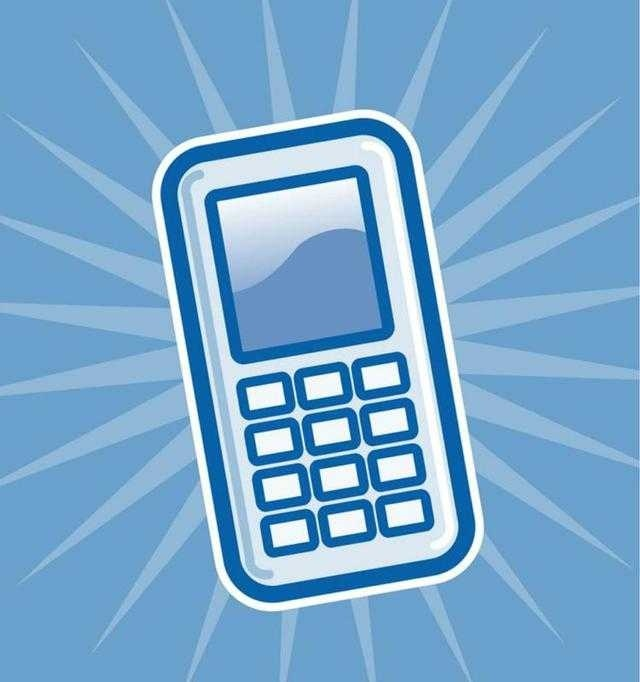

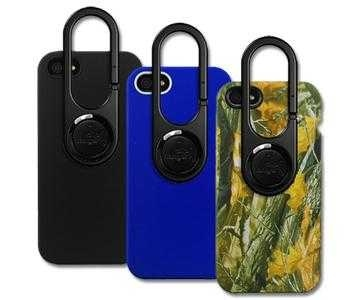

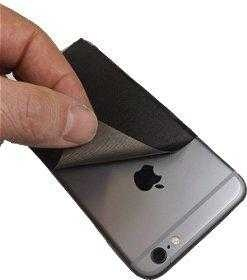

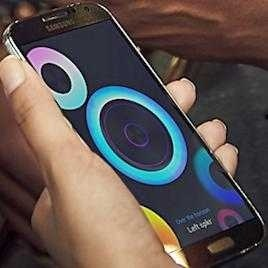

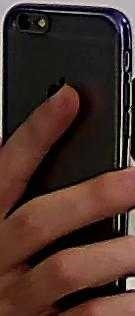

In [35]:
from IPython.display import Image, display
import glob

result_images = glob.glob("/content/threat_detection_results/*.jpg")

print("Quantidade de imagens processadas:", len(result_images))

for img in result_images[:5]:
    display(Image(filename=img))

## V2 - Avaliacao robusta e deploy em tempo real

Nesta secao, vamos adicionar:
- Metricas completas (mAP, precision, recall)
- Sweep de threshold por IoU
- Logica temporal anti-flicker para video/webcam
- Registro de evidencias para auditoria
- Exportacao ONNX e benchmark de latencia/FPS

In [36]:
# Dependencias para avaliacao e visualizacao
!pip install -q scikit-learn seaborn matplotlib pandas onnx onnxruntime

In [37]:
import os
import glob
import time
import json
import csv
from pathlib import Path
from collections import deque

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ultralytics import YOLO

### 1) Avaliacao completa de deteccao

In [39]:
# Resolve automaticamente o caminho do melhor modelo
candidate_weights = [
    "/content/runs/mobile_phone_detector/weights/best.pt",
    "/content/runs/mobile_phone_detector-2/weights/best.pt",
]
found = [p for p in candidate_weights if os.path.exists(p)]

if not found:
    found = sorted(glob.glob("/content/runs/**/weights/best.pt", recursive=True))

if not found:
    raise FileNotFoundError("Nenhum best.pt encontrado em /content/runs")

best_weights_path = found[-1]
print("Usando pesos:", best_weights_path)
best_model = YOLO(best_weights_path)

# Metricas oficiais do Ultralytics no split de validacao
val_metrics = best_model.val(
    data="/content/mobile_phone_yolo/data.yaml",
    split="val",
    imgsz=640,
    conf=0.001,
    iou=0.6,
    plots=True,
    save_json=False,
    verbose=True,
)

print("\nResumo de metricas:")
print("mAP50:", float(val_metrics.box.map50))
print("mAP50-95:", float(val_metrics.box.map))
print("Precision:", float(val_metrics.box.mp))
print("Recall:", float(val_metrics.box.mr))

Usando pesos: /content/runs/mobile_phone_detector-2/weights/best.pt
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 805.6±352.6 MB/s, size: 15.6 KB)
val: Scanning /content/mobile_phone_yolo/labels/val.cache... 0 images, 356 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 356/356 114.9Mit/s 0.0s
WARNING ⚠️ Labels are missing or empty in /content/mobile_phone_yolo/labels/val.cache, training may not work correctly. See https://docs.ultralytics.com/datasets for dataset formatting guidance.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 8.9it/s 2.6s


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:657: RuntimeWarning: Mean of empty slice.
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:703: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:703: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/ultraly

                   all        356          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels
Speed: 2.5ms preprocess, 3.4ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /content/runs/detect/val-6

Resumo de metricas:
mAP50: 0.0
mAP50-95: 0.0
Precision: 0.0
Recall: 0.0


### 2) Sweep de threshold (IoU >= 0.5)

Seleciona automaticamente um threshold de confianca com base em Precision, Recall e F1.

Melhor threshold por F1: 0.1
precision    0.0
recall       0.0
f1           0.0
Name: 0, dtype: float64


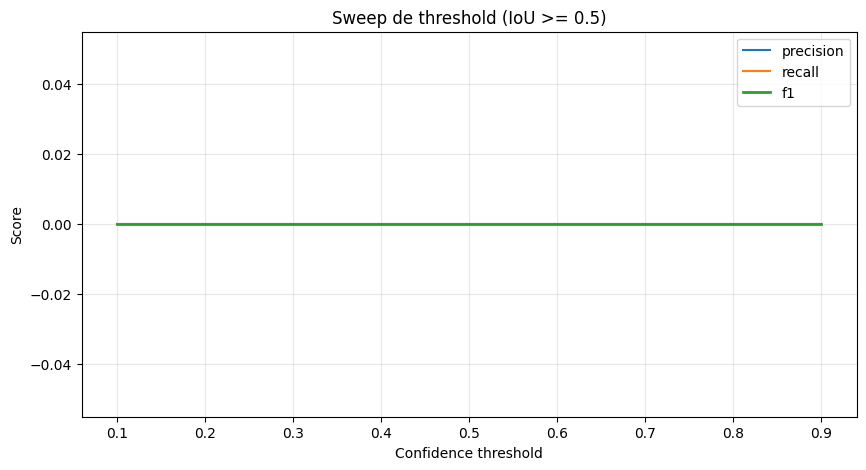

In [41]:
def yolo_to_xyxy(xc, yc, w, h, img_w, img_h):
    x1 = (xc - w / 2.0) * img_w
    y1 = (yc - h / 2.0) * img_h
    x2 = (xc + w / 2.0) * img_w
    y2 = (yc + h / 2.0) * img_h
    return [x1, y1, x2, y2]

def compute_iou(box_a, box_b):
    xa1, ya1, xa2, ya2 = box_a
    xb1, yb1, xb2, yb2 = box_b
    inter_x1 = max(xa1, xb1)
    inter_y1 = max(ya1, yb1)
    inter_x2 = min(xa2, xb2)
    inter_y2 = min(ya2, yb2)
    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h
    area_a = max(0.0, xa2 - xa1) * max(0.0, ya2 - ya1)
    area_b = max(0.0, xb2 - xb1) * max(0.0, yb2 - yb1)
    union = area_a + area_b - inter_area
    return inter_area / union if union > 0 else 0.0

def load_gt_boxes(label_path, img_w, img_h):
    gt = []
    if not os.path.exists(label_path): return gt
    with open(label_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5: continue
            cls_id, xc, yc, w, h = map(float, parts)
            gt.append((int(cls_id), yolo_to_xyxy(xc, yc, w, h, img_w, img_h)))
    return gt

def evaluate_thresholds(model, images_dir, labels_dir, thresholds, iou_thr=0.5):
    image_paths = sorted(glob.glob(os.path.join(images_dir, "*.jpg")) + glob.glob(os.path.join(images_dir, "*.png")))
    rows = []
    for conf_thr in thresholds:
        tp, fp, fn = 0, 0, 0
        for img_path in image_paths:
            img = cv2.imread(img_path)
            if img is None: continue
            img_h, img_w = img.shape[:2]
            lbl_path = os.path.join(labels_dir, f"{Path(img_path).stem}.txt")
            gt = load_gt_boxes(lbl_path, img_w, img_h)
            preds = []
            result = model.predict(img, conf=float(conf_thr), verbose=False)[0]
            if result.boxes is not None:
                for b, c, cf in zip(result.boxes.xyxy.cpu().numpy(), result.boxes.cls.cpu().numpy(), result.boxes.conf.cpu().numpy()):
                    preds.append((int(c), b.tolist(), float(cf)))
            gt_used = [False] * len(gt)
            pred_used = [False] * len(preds)
            for pi, (p_cls, p_box, _) in enumerate(preds):
                best_iou, best_gi = 0.0, -1
                for gi, (g_cls, g_box) in enumerate(gt):
                    if gt_used[gi] or p_cls != g_cls: continue
                    iou = compute_iou(p_box, g_box)
                    if iou > best_iou: best_iou, best_gi = iou, gi
                if best_gi >= 0 and best_iou >= iou_thr:
                    gt_used[best_gi] = pred_used[pi] = True
                    tp += 1
            fp += sum(1 for used in pred_used if not used)
            fn += sum(1 for used in gt_used if not used)
        precision = tp / (tp + fp + 1e-9)
        recall = tp / (tp + fn + 1e-9)
        f1 = 2 * precision * recall / (precision + recall + 1e-9)
        rows.append({"conf": conf_thr, "precision": precision, "recall": recall, "f1": f1})
    return pd.DataFrame(rows)

# --- Código Original ---
thresholds = np.round(np.arange(0.10, 0.95, 0.05), 2)
metrics_df = evaluate_thresholds(
    model=best_model,
    images_dir="/content/mobile_phone_yolo/images/val",
    labels_dir="/content/mobile_phone_yolo/labels/val",
    thresholds=thresholds,
    iou_thr=0.5,
)

best_row = metrics_df.sort_values("f1", ascending=False).iloc[0]
print("Melhor threshold por F1:", float(best_row["conf"]))
print(best_row[["precision", "recall", "f1"]])

plt.figure(figsize=(10, 5))
plt.plot(metrics_df["conf"], metrics_df["precision"], label="precision")
plt.plot(metrics_df["conf"], metrics_df["recall"], label="recall")
plt.plot(metrics_df["conf"], metrics_df["f1"], label="f1", linewidth=2)
plt.xlabel("Confidence threshold")
plt.ylabel("Score")
plt.title("Sweep de threshold (IoU >= 0.5)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### 3) Inferencia em video/webcam com logica temporal, histerese e evidencias

In [42]:
def run_realtime_detection(
    model,
    source=0,
    conf_thr=0.35,
    output_video="/content/threat_realtime_output.mp4",
    evidence_dir="/content/threat_evidence",
    log_csv="/content/threat_events.csv",
    cooldown_frames=45,
):
    os.makedirs(evidence_dir, exist_ok=True)
    filter_state = TemporalThreatFilter(window_size=20, trigger_ratio=0.6, release_ratio=0.3)

    cap = cv2.VideoCapture(source)
    if not cap.isOpened():
        raise RuntimeError("Nao foi possivel abrir a webcam/video. Verifique o source.")

    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps <= 0:
        fps = 30.0
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(output_video, fourcc, fps, (w, h))

    frame_idx = 0
    cooldown = 0

    with open(log_csv, "w", newline="", encoding="utf-8") as f:
        csv_writer = csv.writer(f)
        csv_writer.writerow(["frame", "timestamp_sec", "alert_score", "max_conf", "evidence_path"])

        while True:
            ok, frame = cap.read()
            if not ok:
                break

            result = model.predict(frame, conf=conf_thr, verbose=False)[0]
            frame_has_threat = False
            max_conf = 0.0

            if result.boxes is not None and len(result.boxes) > 0:
                for b in result.boxes:
                    x1, y1, x2, y2 = map(int, b.xyxy[0].tolist())
                    conf = float(b.conf[0].item())
                    max_conf = max(max_conf, conf)

                    threat = is_threat((x1, y1, x2, y2), w, h)
                    if threat:
                        frame_has_threat = True
                        color = (0, 0, 255)
                        label = f"THREAT {conf:.2f}"
                    else:
                        color = (0, 255, 0)
                        label = f"mobile_phone {conf:.2f}"

                    cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
                    cv2.putText(frame, label, (x1, max(30, y1 - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

            alert, score = filter_state.update(frame_has_threat)
            timestamp_sec = frame_idx / fps

            if alert:
                # Aplicar borramento (blur) em toda a imagem
                frame = cv2.GaussianBlur(frame, (99, 99), 30)

                overlay = frame.copy()
                cv2.rectangle(overlay, (0, 0), (w, h), (0, 0, 0), -1)
                frame = cv2.addWeighted(overlay, 0.5, frame, 0.5, 0)

                # Mensagem de bloqueio
                cv2.putText(frame, "TELA BLOQUEADA", (30, h // 2 - 20), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 255), 4)
                cv2.putText(frame, "CELULAR DETECTADO", (30, h // 2 + 30), cv2.FONT_HERSHEY_SIMPLEX, 1.1, (255, 255, 255), 3)

                if cooldown <= 0:
                    evidence_path = os.path.join(evidence_dir, f"frame_{frame_idx:06d}.jpg")
                    cv2.imwrite(evidence_path, frame)
                    csv_writer.writerow([frame_idx, round(timestamp_sec, 3), round(score, 4), round(max_conf, 4), evidence_path])
                    cooldown = cooldown_frames

            if cooldown > 0:
                cooldown -= 1

            writer.write(frame)
            frame_idx += 1

    cap.release()
    writer.release()
    print("Processamento concluido.")
    print("Video de saida:", output_video)
    print("Evidencias:", evidence_dir)
    print("Log CSV:", log_csv)

### 4) Hard negative mining (coletar falsos positivos)

Salva amostras em que o modelo detectou celular, mas nao existe label no ground truth. Essas amostras ajudam muito no proximo ciclo de retreino.

In [44]:
import os
import glob
import cv2
from pathlib import Path

def collect_hard_negatives(model, images_dir, labels_dir, out_dir, conf_thr=0.35):
    os.makedirs(out_dir, exist_ok=True)
    img_paths = sorted(glob.glob(os.path.join(images_dir, "*.jpg")) + glob.glob(os.path.join(images_dir, "*.png")))

    saved = 0
    for img_path in img_paths:
        stem = Path(img_path).stem
        lbl_path = os.path.join(labels_dir, f"{stem}.txt")

        # Se já existe label no ground truth, não é um hard negative (falso positivo)
        has_gt = os.path.exists(lbl_path) and os.path.getsize(lbl_path) > 0
        if has_gt:
            continue

        img = cv2.imread(img_path)
        if img is None:
            continue

        pred = model.predict(img, conf=conf_thr, verbose=False)[0]
        has_pred = pred.boxes is not None and len(pred.boxes) > 0

        if has_pred:
            save_path = os.path.join(out_dir, os.path.basename(img_path))
            cv2.imwrite(save_path, img)
            saved += 1

    print(f"Hard negatives salvos: {saved}")
    print("Diretorio:", out_dir)

# Chamada da função
collect_hard_negatives(
    model=best_model,
    images_dir="/content/mobile_phone_yolo/images/val",
    labels_dir="/content/mobile_phone_yolo/labels/val",
    out_dir="/content/hard_negatives",
    conf_thr=0.35
)

Hard negatives salvos: 0
Diretorio: /content/hard_negatives


### 5) Exportacao ONNX e benchmark de inferencia

In [45]:
# Exporta o modelo para ONNX
onnx_path = best_model.export(format="onnx", dynamic=True, simplify=True)
print("Modelo ONNX exportado em:", onnx_path)


def benchmark_model(model, image_paths, conf=0.35):
    times = []
    for p in image_paths:
        img = cv2.imread(p)
        if img is None:
            continue

        t0 = time.perf_counter()
        _ = model.predict(img, conf=conf, verbose=False)
        t1 = time.perf_counter()
        times.append((t1 - t0) * 1000.0)

    if not times:
        print("Sem imagens validas para benchmark.")
        return

    avg_ms = float(np.mean(times))
    p95_ms = float(np.percentile(times, 95))
    fps = 1000.0 / avg_ms if avg_ms > 0 else 0.0

    print(f"Latencia media: {avg_ms:.2f} ms/frame")
    print(f"Latencia p95:   {p95_ms:.2f} ms/frame")
    print(f"FPS estimado:   {fps:.2f}")


bench_imgs = sorted(glob.glob("/content/mobile_phone_yolo/images/val/*.jpg"))[:100]
benchmark_model(best_model, bench_imgs, conf=0.35)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/runs/mobile_phone_detector-2/weights/best.pt' with input shape (1, 3, 800, 800) BCHW and output shape(s) (1, 5, 13125) (5.9 MB)
requirements: Ultralytics requirement ['onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 5 packages in 185ms
Prepared 1 package in 3.20s
Installed 1 package in 41ms
 + onnxruntime-gpu==1.26.0

requirements: AutoUpdate success ✅ 3.5s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.93...
ONNX: export success ✅ 6.7s, saved as '/content/runs/mobile_phone_detector-2/weights/best.onnx' (12.1 MB)

Export complete (7.2s)
Results saved 

In [46]:
# Fazendo um Benchmark mais completo (Comparando PyTorch vs ONNX vs TensorRT localmente se disponivel)
!yolo benchmark model=/content/runs/mobile_phone_detector-2/weights/best.pt imgsz=800 half=False data=/content/mobile_phone_yolo/data.yaml device=cpu
# Obs: mude device=cpu para device=0 se tiver GPU NVIDIA para um benchmark real

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2055.6±1261.0 MB/s, size: 81.9 KB)
val: Scanning /content/mobile_phone_yolo/labels/val.cache... 0 images, 356 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 356/356 53.3Mit/s 0.0s
WARNING ⚠️ Labels are missing or empty in /content/mobile_phone_yolo/labels/val.cache, training may not work correctly. See https://docs.ultralytics.com/datasets for dataset formatting guidance.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 356/356 5.4it/s 1:06
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:839: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
                   all        356          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, can

Para testar o resultado em tempo real, execute localmente o notebook em seu ambiente Jupyter ou VS Code. Basta executar a célula abaixo:

python
run_realtime_detection(best_model, source=0)

Testando detecção com o arquivo: /content/mobile_phone_yolo/images/val/PM8LJ7C1SCZ7.jpg


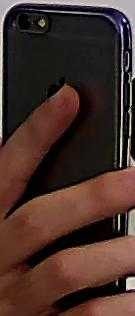


Lembrete: Para usar a webcam (source=0), você deve baixar este notebook e executá-lo localmente (Anaconda, VS Code ou Jupyter).


In [57]:
import glob

# Como estamos no Colab, vamos testar com um arquivo de imagem em vez da webcam
test_images = glob.glob("/content/mobile_phone_yolo/images/val/*.jpg")

if test_images:
    test_source = test_images[4]
    print(f"Testando detecção com o arquivo: {test_source}")

    # Nota: run_realtime_detection foi projetada para vídeo (VideoCapture),
    # para fotos usamos o predict direto como feito anteriormente.
    results = best_model.predict(test_source, conf=0.25)
    results[0].show()
else:
    print("Nenhuma imagem encontrada para teste.")

print("\nLembrete: Para usar a webcam (source=0), você deve baixar este notebook e executá-lo localmente (Anaconda, VS Code ou Jupyter).")